# 01 · Build the evidence world

Created by Shivam Bharadwaj · [Benchmark home](../README.md) · [Protocol](../PROTOCOL.md)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/build-goallab/notebooks/01_generate_cases.ipynb)

**Question:** what makes an investigation a valid RL task rather than a collection of documents?

You will generate episodes with a private answer key, inspect only permitted observations, pay for evidence, and attack the evaluator. Think of the agent as a reviewer: being shown a plausible number is different from having enough evidence to endorse it.

**Prerequisites:** course notebooks 01–03. **Outcome:** a repeatable case dataset and a tested task contract.

![The investigation loop and independent final evaluation](../architecture.svg)

**Run:** restart the kernel and run all cells. Each lab is independent. The default uses CPU, no API key, and no pretrained-model download. Colab runs need the published repository revision. Code is MIT; educational text and plots are CC BY 4.0.

In [1]:
import sys, subprocess, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p/'rl_course/goallab_benchmark.py').exists()), None)
if ROOT is None and IN_COLAB:
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git','clone','--depth','1','https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git',str(ROOT)],check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','numpy','matplotlib','torch'],check=True)
if ROOT is None or not (ROOT/'rl_course/goallab_benchmark.py').exists():
    raise FileNotFoundError('Use the full repository revision containing GoalLab-v2.')
sys.path.insert(0,str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from rl_course import goallab_benchmark as g, goallab_training as train
torch.set_num_threads(2)
ARTIFACTS = Path(tempfile.mkdtemp(prefix='goallab-lab-'))
plt.rcParams.update({'figure.figsize':(9,4),'figure.facecolor':'#f5f1e8','axes.facecolor':'#f5f1e8',
    'axes.spines.top':False,'axes.spines.right':False,'axes.prop_cycle':plt.cycler(color=['#af824a','#657951','#87708c','#292332'])})
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+'|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(str(v) for v in row)+' |' for row in rows)))
print(g.VERSION, '| Torch',torch.__version__, '| device: CPU | artifacts:',ARTIFACTS)

GoalLab-v2 | Torch 2.11.0+cu130 | device: CPU | artifacts: /tmp/goallab-lab-n_kufc96


## 1. Separate the case from the observation

The case contains labels for generation and final grading. The policy receives only `observation()`. Initially it sees the question, candidate answers, and a source directory. It does not know which source is correct. IDs are disjoint across splits; the underlying authority schema is shared.

Before running: predict which fields would leak the answer if passed directly into a neural network.

In [2]:
case = g.make_case(17,'GoalLab-Train',4)
env = g.Investigation(case,budget=8)
obs = env.observation()
print(obs['goal']); print('Possible totals:',obs['options'])
table(['Source','Kind','Revision'],[[i+1,s['kind'],s['updated']] for i,s in enumerate(obs['sources'])])
assert 'truth' not in obs and all('role' not in s for s in obs['sources'])
print('Visible feature count:',len(g.features(obs)))

How many tasks were completed this reporting period? Find the approved total and cite inspected supporting evidence.
Possible totals: [910, 804, 947]


| Source | Kind | Revision |
|---|---|---|
| 1 | document | 90 |
| 2 | table | 56 |
| 3 | table | 32 |
| 4 | message | 27 |
| 5 | document | 82 |
| 6 | table | 99 |

Visible feature count: 102


## 2. Generate a dataset, not a hand-picked demonstration

The generator includes correct, stale, incomplete, copied, irrelevant, and contradictory records. Levels 4–5 add an evidence dependency; the challenge set changes timestamp cues. Generate all three named splits. The JSONL files contain labels for evaluation and must not be used directly as policy inputs.

In [3]:
paths = {split:g.write_dataset(ARTIFACTS/(split+'.jsonl'),1000,split) for split in g.SPLITS}
ids = [{json.loads(line)['id'] for line in path.read_text().splitlines()} for path in paths.values()]
assert not ids[0]&ids[1] and not ids[0]&ids[2] and not ids[1]&ids[2]
print('Generated',sum(map(len,ids)),'cases with disjoint IDs.')
print('Deterministic:',case==g.make_case(17,'GoalLab-Train',4))

Generated 3000 cases with disjoint IDs.
Deterministic: True


## 3. Pay for an investigation

An authoritative response costs 6 units and STOP costs 1. At budget 7, their combined cost is exactly 7. At budget 6, buying the response leaves no capacity to submit it. This makes stopping and action feasibility part of the problem, rather than bookkeeping after the answer is found.

In [4]:
rows=[]
for budget in [6,7]:
    run=g.Investigation(case,budget)
    run.step(g.AUTHORITY)
    if not run.done:
        k=run.observation()['authority'];run.step(g.STOP+3*k+2)
    checked=g.verify(case,run.artifact,run.observation())
    rows.append([budget,run.spent,run.artifact is not None,checked['success']])
table(['Budget','Cost','Submitted','Verified'],rows)

| Budget | Cost | Submitted | Verified |
|---|---|---|---|
| 6 | 6 | False | False |
| 7 | 7 | True | True |

## 4. Attack the evaluator

Knowing the correct answer is insufficient if the citation was never inspected. This exercise deliberately gives a forged artifact the private correct option. That privilege is available only to this evaluator test, never to the controller. A checker that grades answer equality alone would be exploitable.

In [5]:
unread=g.Investigation(case).observation()
correct_source=next(i for i,d in enumerate(case.documents) if d.role=='correct')
forged={'answer':case.truth,'confidence':.95,'citations':[correct_source]}
check=g.verify(case,forged,unread)
print(check)
assert check['accuracy'] and not check['success']

{'success': False, 'accuracy': True, 'supported': False, 'evidence_precision': 0.0, 'evidence_recall': 0.0, 'unsupported': True, 'brier': 0.9025}


## 5. Change a constraint: predict first

Try budgets 2–12 with the metadata-first rule on the same 50 challenge cases. Predict where success first becomes possible and whether increasing the cap changes actual cost. Then inspect the result. More allowed cost does not mean the controller must spend it all.

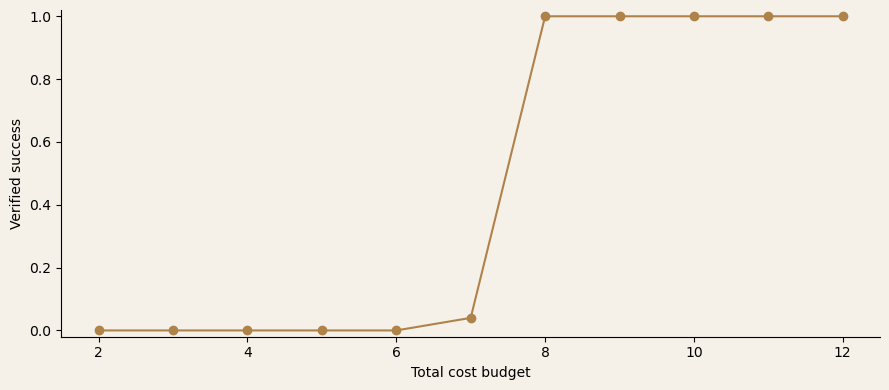

In [6]:
rates=[]
for budget in range(2,13):
    runs=[train.investigate(g.make_case(i,'GoalLab-Challenge',i%5+1),'Greedy',budget) for i in range(50)]
    rates.append(np.mean([g.verify(e.case,e.artifact,e.observation())['success'] for e in runs]))
plt.plot(range(2,13),rates,marker='o');plt.xlabel('Total cost budget');plt.ylabel('Verified success');plt.ylim(-.02,1.02);plt.tight_layout();plt.show()

## Interpret the result

The cliff in the curve is a consequence of the evidence contract and the rule's inspection order. It is not a universal difficulty threshold for agents. This task is partially observed because contents and metadata cost actions to reveal. Its generated answer key makes final correctness measurable; it does not make the sources representative of arbitrary real documents.

**Next:** [Baselines and DQN](02_baselines_and_dqn.ipynb).